In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [9]:
import pandas as pd
import numpy as np


In [12]:
from sklearn.datasets import fetch_openml



In [13]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (70000, 784)
Shape of y: (70000,)


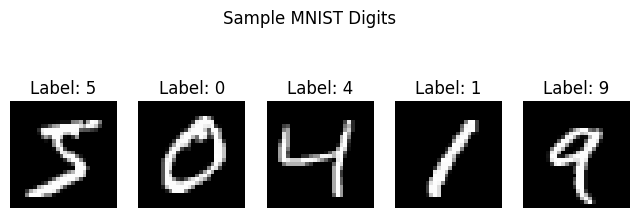

In [14]:
plt.figure(figsize=(8, 3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.suptitle("Sample MNIST Digits")
plt.show()


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (56000, 784)
Testing samples: (14000, 784)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy with K=3:", accuracy)


Accuracy with K=3: 0.9455


In [18]:
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc}")


K = 3, Accuracy = 0.9455
K = 5, Accuracy = 0.9444285714285714
K = 7, Accuracy = 0.9438571428571428
K = 9, Accuracy = 0.9405714285714286


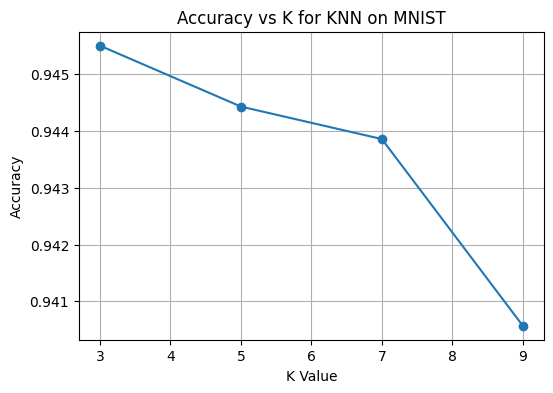

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K for KNN on MNIST")
plt.grid(True)
plt.show()


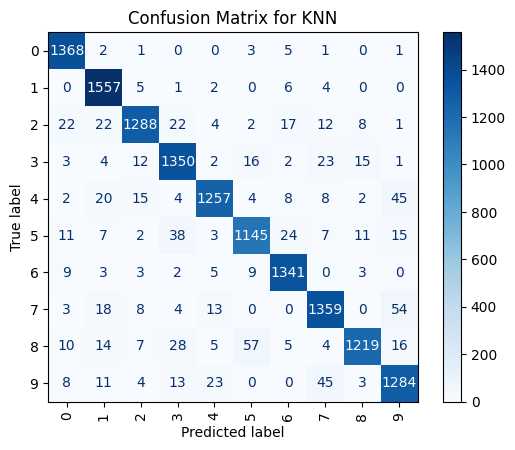

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix for KNN")
plt.show()


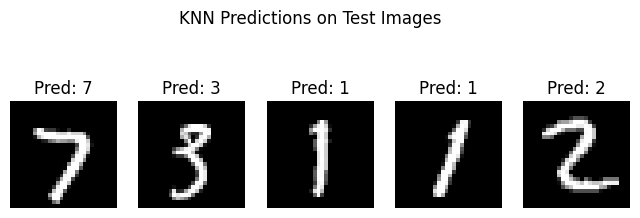

In [24]:
plt.figure(figsize=(8, 3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.suptitle("KNN Predictions on Test Images")
plt.show()
